In [1]:
import sys, math, time; print(sys.version)
import matplotlib.pyplot as plt
from matplotlib import patches
import numpy as np

rng = np.random.default_rng()
def lines(a): return a.split('\n')

def rot_z(vec, radians): #{
    mrot = np.array([[np.cos(radians), -np.sin(radians), 0], 
                     [np.sin(radians),  np.cos(radians), 0], 
                     [0,                0,               1]])
    return np.dot(mrot, vec)
#}

c = 29979245800 # speed of light in cm/sec

3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:35:20) [Clang 16.0.6 ]


In [128]:
# [0.5, 1.5] T - MRI ([5000, 15000] Gauss)
# .01 T - strong refrigerator magnet (100 Gauss)
# [.000025, .000065] T - Earth's field ([.25, .65] Gauss)

# Nagoaka "short solenoid" error/leakage correction coefficient
def Nagaoka(r, l): return 1 / (1 + 0.528*math.pow(2*r/l, 0.846))

# Coil/spool size and turns
wdiam = 0.51054e-3 # AWG 24 wire diameter
wESRD = 84.1976e-3 # Ω/m, AWG 24 wire resistance density
cturns = 15        # number of coil turns (per layer)
clayers = 8        # number of coil layers
srad = 2e-2        # radius of the spool 
mu0 = 4e-7 * math.pi

Re = 40.2
Vsig = 3.3
N = cturns*clayers
l = cturns*wdiam
r = srad + (clayers*wdiam*0.5) # centering Nagaoka radius at mid-clayers
A = math.pi * r**2
k = Nagaoka(r, l)
L = k * mu0 * A * N**2 / l

wlen, wrad = 0, srad + wdiam*0.5
for il in range(clayers):
    wlen += 2 * np.pi * wrad * cturns
    wrad += wdiam

print(f'N: {N} turns')
print(f'spool diameter: {srad * 2e3:.2f} mm')
print(f'spool height: {l * 1e3:.2f} mm ({(l + 1.5*wdiam) * 1e3:.3f} mm w/1.5*wdiam)')
print(f'layer radial thickness: {clayers * wdiam * 1e3:.2f} mm')
print(f'L: {L * 1e6:.01f} μH (k: {k:.3f})')
print(f'wire ESR: {wlen * wESRD:.3f} Ω (len: {wlen:.3f}) m\n')

# Given I, find B
I = Vsig / Re 
B = (mu0 * N * I) / (2 * r)
print(f'Vsig: {Vsig} V (offset/amplitude: {Vsig/2})')
print(f'B: {B * 1e4:.2f} Gauss ([{B / 0.000065:.1f}, {B / 0.000045:.1f}, {B / 0.000025:.1f}] times Earth-B-Field)')

# Given B, find I
# B = 0.000650
# I = (B * 2 * r) / (mu0 * N)
print(f'I: {round(I * 1e3)} mA (Re: {round(Vsig / I)} Ω, Pmax: {round(Re/2 * I**2 * 1e3)} mW) ')
# Note: the 20Ω-1μF RC filter adds a few mA of current thru the Emag at higher frequecies, see CircuitLab

# These only work for long solenoids (l >> r)
# B = (mu0 * N * I) / l
# I = (B * l) / (mu0 * N)

# Circuit lab signal ampl rolloff:
# [0, 6k] Hz : 2.8 V
# (6k, 9k] Hz : 2.7 V
# (9k, 12k] Hz : 2.6 V
# (12k, 15k] Hz : 2.5 V
# (15k, 17.5k] Hz : 2.4 V
# (17.5k, 20k] Hz : 2.3 V

N: 120 turns
spool diameter: 40.00 mm
spool height: 7.66 mm (8.424 mm w/1.5*wdiam)
layer radial thickness: 4.08 mm
L: 1085.9 μH (k: 0.301)
wire ESR: 1.399 Ω (len: 16.619) m

Vsig: 3.3 V (offset/amplitude: 1.65)
B: 2.81 Gauss ([4.3, 6.2, 11.2] times Earth-B-Field)
I: 82 mA (Re: 40 Ω, Pmax: 135 mW) 


In [125]:
x = 40 + 2*4.08 + 4
(x/2 + 16) * 2

# (l + 1.5*wdiam) * 1e3, 12.17054 / 2

1110 / 39.37
422 / 39.37
15 * 39.37

wmmc = (1110 - 422*2) / 39.37

(40 - wmmc) / 2, 16

x = (l + 1.5*wdiam) * 1e3
x - 5 - 1.6

# 4.9 + 3.5 + 0.6
# 2 + 1.6 - 6.1
# 28 + 12.273
# 9.9 + 0.2

x = 6.6/2 + 12
deg = np.arcsin(x / 45) * (180/np.pi)
print(x, deg)

deg = 10
x = 45 * np.sin(deg * (np.pi/180))
print(x, deg, x - 3.3)

x = 40.859 / 2
deg = np.arcsin(x / 45) * (180/np.pi)
print(x, deg, x - 3.3)

30.782/2 - 6.6/2

15.3 19.876874070078834
7.814167995011865 10 4.514167995011865
20.4295 26.99989641501032 17.1295


12.091000000000001

lyr 1 : r = 2.026 cm : s = 0.354 mm
lyr 2 : r = 2.077 cm : s = 0.362 mm
lyr 3 : r = 2.128 cm : s = 0.371 mm
lyr 4 : r = 2.179 cm : s = 0.380 mm
lyr 5 : r = 2.230 cm : s = 0.389 mm
lyr 6 : r = 2.281 cm : s = 0.398 mm


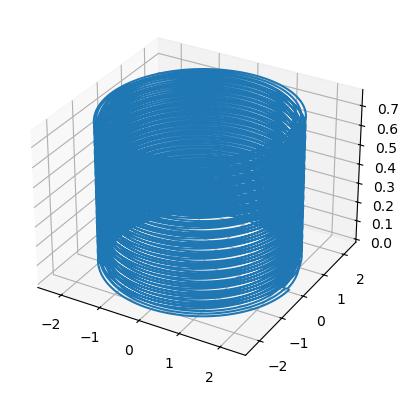

In [31]:
# Create dl vectors for the coil (num steps per rotation)
nsteps = 360
thetas, dta = np.linspace(0, 2*np.pi, endpoint=False, retstep=True, num=nsteps)
dlhat = [rot_z(np.array([0,1,0]), radians) for radians in thetas]
lpos = np.zeros((clayers * cturns * nsteps, 3))
dl = np.zeros((clayers * cturns * nsteps, 3))

ii = 0
for lyr in range(clayers): #{
    srr = srad + (wdiam * 0.5) + (lyr * wdiam)
    s = srr * dta
    
    print(f'lyr {lyr+1} : r = {srr * 1e2:.3f} cm : s = {s * 1e3:.3f} mm')
    szz, zstep = (0, wdiam/nsteps) if lyr % 2 == 0 else (wdiam*cturns, -wdiam/nsteps)
    
    for trn in range(cturns): #{
        for n in range(nsteps): #{
            lpos[ii] = rot_z(np.array([srr, 0, szz]), thetas[n]) * 1e2
            dl[ii] = dlhat[n] * s * 1e2
            szz += zstep
            ii += 1
        #}
    #}
#}

# print(f'{(srr + (wdiam * 0.5)) * 1e2:.3f} cm')

ax = plt.figure().add_subplot(projection='3d')
ax.plot(lpos[:,0], lpos[:,1], lpos[:,2], label='parametric curve')
# ax.set_xlim3d(-2, 2)
# ax.set_ylim3d(-2, 2)
# ax.set_zlim3d(-2, 2)

# rcm, lcm, 
# print(f'spool radius: {srad * 1e2:.1f} cm')
# print(f'spool height: {l * 1e2:.3f} cm')
# print(f'layer radial thickness: {clayers * wdiam * 1e2:.3f} cm')

### B-Field of Current Wire Calculation
![dBdl](./dBequation.jpeg)

In [ ]:
nfldsteps = 20
X, Z = np.meshgrid(np.linspace(-4, 4, nfldsteps), np.linspace(-2, 3, nfldsteps)) # cm
Icontrib = I * 3e-9 * 29979245800e-1 # esu/cm (i.e. I/c in esu units)

initial = time.time()
dBx = np.zeros(X.shape)
dBz = np.zeros(Z.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        dB = np.zeros((3,))
        spos = np.array([X[i,j], 0., Z[i,j]])
        for k in range(lpos.shape[0]):
            rfld = spos - lpos[k,:]
            rfldsqr = rfld.dot(rfld)
            rhat = rfld/np.sqrt(rfldsqr)
            dB += np.cross(dl[k,:], rhat) * (Icontrib / rfldsqr)
        dBx[i,j] = dB[0]
        dBz[i,j] = dB[2]

    print(f'{i+1}/20 : {time.time()-initial:.2f} s')
        
# dBx, dBx.shape, dBz, dBz.shape, X.shape

In [ ]:
fig, ax = plt.subplots()
scale = 3 * max(dBx.max(), dBz.max())
print(scale, max(dBx.max(), dBz.max()))

# Coil boundaries
ax.add_patch(patches.Rectangle((-(srad + clayers*wdiam) * 1e2, 0), clayers*wdiam*1e2, l*1e2, linewidth=1, edgecolor='r', facecolor='none'))
ax.add_patch(patches.Rectangle((srad * 1e2, 0), clayers*wdiam*1e2, l*1e2, linewidth=1, edgecolor='r', facecolor='none'))
q = ax.quiver(X, Z, dBx, dBz, pivot='mid', angles='xy', scale_units='xy', scale=scale)

### Self-Inductance L Calculation

In [32]:
# Estimates B-field flux through two (circular) cross-sections, one at the 
# bottom turn of the coil, one at the "middle" turn, then linearly interpolates 
# those (symmetric) values (per turn group) to sum across all N coil turns 

nthtsteps = 20
nradsteps = 20

midturn = cturns//2
ht = wdiam * 0.5 * 1e2 # bottom turn
mindist = (wdiam*0.5 * 1e2)**2 # to exclude Bfield contribs "within wire"
EMF_I = [0, 0] # the value such that: EMF = I * EMF_I

initial = time.time()
for jj in range(2):
    # Inner part of cross-section (stops at coil wires)
    rad = np.linspace(0, srad * 1e2, endpoint=True, num=nradsteps+1)
    for i in range(1, len(rad)):
        da = np.array([0, 0, (np.pi * (rad[i]**2 - rad[i-1]**2)) / nthtsteps])
        for tht in np.linspace(0, 2*np.pi, endpoint=False, num=nthtsteps):
            dB_I = np.zeros((3,))
            spos = rot_z(np.array([(rad[i-1] + rad[i])/2, 0, ht]), tht)
            for k in range(lpos.shape[0]):
                rfld = spos - lpos[k,:]
                rfldsqr = rfld.dot(rfld)
                rhat = rfld/np.sqrt(rfldsqr)
                dB_I += np.cross(dl[k,:], rhat) / (c * rfldsqr)
            #}
            
            EMF_I[jj] += dB_I.dot(da)
        
        print(f'inner disc ({"bot" if jj == 0 else "mid"}) : ring {i}/{nradsteps} : {time.time()-initial:.2f} s')
    #}
    
    # And outer part, one "da" per wire-width (i.e. clayer)
    rad = np.linspace(srad * 1e2, (srad + clayers*wdiam) * 1e2, endpoint=True, num=clayers+1)
    for i in range(1, len(rad)):
        da = np.array([0, 0, (np.pi * (rad[i]**2 - rad[i-1]**2)) / nthtsteps])
        for tht in np.linspace(0, 2*np.pi, endpoint=False, num=nthtsteps):
            dB_I = np.zeros((3,))
            spos = rot_z(np.array([(rad[i-1] + rad[i])/2, 0, ht]), tht)
            for k in range(lpos.shape[0]):
                rfld = spos - lpos[k,:]
                rfldsqr = rfld.dot(rfld)
                if rfldsqr <= mindist: continue
                rhat = rfld/np.sqrt(rfldsqr)
                dB_I += np.cross(dl[k,:], rhat) / (c * rfldsqr)
            #}
            
            EMF_I[jj] += dB_I.dot(da)
        
        print(f'in-coil-bundle ({"bot" if jj == 0 else "mid"}) : ring {i}/{clayers} : {time.time()-initial:.2f} s')
    #}

    # Now set to "middle" turn
    ht += midturn * wdiam * 1e2
    print()
#}

totalEMF_I = 0
even = (cturns % 2 == 0)
lerpt = np.linspace(EMF_I[0], EMF_I[1], endpoint=True, num=(midturn if even else midturn+1))
for i in range(len(lerpt)):
    cnt = 2 if i < len(lerpt)-1 or even else 1
    totalEMF_I += lerpt[i]*clayers*cnt

L_e = totalEMF_I / c # Empirical self-inductance in CSG units (sec^2 cm^-1)
print(f'L extrema: [{round(EMF_I[0]*N/c * 1.113e12 * 1e6)}μH, {round(EMF_I[1]*N/c * 1.113e12 * 1e6)}μH]')
print(f'L (nom/interpolated): {L_e * 1.113e12 * 1e6:.2f} μH')

inner disc (bot) : ring 1/20 : 9.51 s
inner disc (bot) : ring 2/20 : 19.01 s
inner disc (bot) : ring 3/20 : 28.56 s
inner disc (bot) : ring 4/20 : 38.03 s
inner disc (bot) : ring 5/20 : 47.63 s
inner disc (bot) : ring 6/20 : 57.32 s
inner disc (bot) : ring 7/20 : 66.90 s
inner disc (bot) : ring 8/20 : 76.92 s
inner disc (bot) : ring 9/20 : 86.35 s
inner disc (bot) : ring 10/20 : 96.19 s
inner disc (bot) : ring 11/20 : 105.88 s
inner disc (bot) : ring 12/20 : 115.62 s
inner disc (bot) : ring 13/20 : 125.37 s
inner disc (bot) : ring 14/20 : 135.17 s
inner disc (bot) : ring 15/20 : 144.91 s
inner disc (bot) : ring 16/20 : 155.24 s
inner disc (bot) : ring 17/20 : 164.86 s
inner disc (bot) : ring 18/20 : 174.42 s
inner disc (bot) : ring 19/20 : 184.00 s
inner disc (bot) : ring 20/20 : 193.44 s
in-coil-bundle (bot) : ring 1/6 : 203.25 s
in-coil-bundle (bot) : ring 2/6 : 213.69 s
in-coil-bundle (bot) : ring 3/6 : 223.50 s
in-coil-bundle (bot) : ring 4/6 : 233.61 s
in-coil-bundle (bot) : ring 

### Self-Inductance Calc for Torus (proof of above algorithm)
![EMF](./emf.jpeg)  
![L](./selfinductance.jpeg)
![torus](./torus.jpeg)

In [ ]:
# Create dl vectors for the torus 
a, b = 0.5, 2.0 # torus inner and outer radius
h = b - a # torus height
N = 50 # number of turns
M = 40  # samples per turn

thetas, dta = np.linspace(0, 2*np.pi, endpoint=False, retstep=True, num=N)
drhat = [rot_z(np.array([1,0,0]), radians) for radians in thetas]
lpos = np.zeros((M * N, 3))
dl = np.zeros((M * N, 3))

li = 0
for n in range(0, N):
    szz, dz = np.linspace(0, h, endpoint=False, retstep=True, num=M//4)
    for i in range(len(szz)):
        lpos[li] = np.array([0, 0, szz[i]]) + (drhat[n] * a)
        dl[li] = np.array([0,0,1]) * h / len(szz)
        li += 1

    srr, dr = np.linspace(a, b, endpoint=False, retstep=True, num=M//4)
    for i in range(len(srr)):
        lpos[li] = np.array([0, 0, h]) + (drhat[n] * srr[i])
        dl[li] = drhat[n] * (b-a) / len(srr)
        li += 1

    szz, dz = np.linspace(h, 0, endpoint=False, retstep=True, num=M//4)
    for i in range(len(szz)):
        lpos[li] = np.array([0, 0, szz[i]]) + (drhat[n] * b)
        dl[li] = -np.array([0,0,1]) * h / len(szz)
        li += 1

    srr, dr = np.linspace(b, a, endpoint=False, retstep=True, num=M//4)
    for i in range(len(srr)):
        lpos[li] = np.array([0, 0, 0]) + (drhat[n] * srr[i])
        dl[li] = -drhat[n] * (b-a) / len(srr)
        li += 1

ax = plt.figure().add_subplot(projection='3d')
ax.plot(lpos[:,0], lpos[:,1], lpos[:,2], label='parametric curve')

In [ ]:
nfldsteps = 20
inset = wdiam * 1e2 # cm
X, Z = np.meshgrid(np.linspace(a+inset, b-inset, nfldsteps), np.linspace(0+inset, h-inset, nfldsteps)) # cm

c = 29979245800 # cm/sec
Icontrib = I * 3e9 / c # esu/cm (i.e. I/c in esu units)

initial = time.time()
EMF, EMF_I = 0, 0
da = np.array([0, (b-a)/nfldsteps * h/nfldsteps, 0])
dBy = np.zeros(X.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        dB = np.zeros((3,))
        dB_I = np.zeros((3,))
        spos = np.array([X[i,j], 0., Z[i,j]])
        for k in range(lpos.shape[0]):
            rfld = spos - lpos[k,:]
            rfldsqr = rfld.dot(rfld)
            rhat = rfld/np.sqrt(rfldsqr)
            dB += np.cross(dl[k,:], rhat) * (Icontrib / rfldsqr)
            dB_I += np.cross(dl[k,:], rhat) / (c * rfldsqr)
        dBy[i,j] = dB[1]
        EMF += dB.dot(da)
        EMF_I += dB_I.dot(da)

    print(f'{i+1}/{nfldsteps} : {time.time()-initial:.2f} s')

EMF *= N
EMF_t = 2 * N**2 * h * np.log(b/a) * Icontrib
print(f'\nempirical EMF: {EMF:.2f} stratvolts')
print(f'theoretical EMF: {EMF_t:.2f} stratvolts')
print(f'percent error: {abs(EMF-EMF_t)/EMF_t * 100:.2f}')

EMF_I *= N
L_e = EMF_I / c
L_t = 2 * N**2 * h * np.log(b/a) / c**2 
print(f'\nempirical L: {L_e * 1.113e12 * 1e6:.2f} μH')
print(f'theoretical L: {L_t * 1.113e12 * 1e6:.2f} μH')
print(f'percent error: {abs(L_e-L_t)/L_t * 100:.2f}')

# 1.113e-12 csg/H

# dBx, dBx.shape, dBz, dBz.shape, X.shape

In [ ]:
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        spos = np.array([X[i,j], 0., Z[i,j]])
        B_t = 2 * N * Icontrib / X[i,j]
        # print(f'{dBy[i,j]:.2f} : {B_t:.2f} : {abs(dBy[i,j] - B_t)}')

In [138]:
a = '''ID	Name	Designator	Footprint	Quantity	Manufacturer Part	Manufacturer	Supplier	Supplier Part	Price
"1"	"15nF"	"C30"	"C0402"	"1"	"CC0402KRX7R9BB153"	"YAGEO(国巨)"	"LCSC"	"C114405"	"0.002"
"2"	"1kΩ"	"R11,R17"	"R0402"	"2"	"0402WGF1001TCE"	"UNI-ROYAL(厚声)"	"LCSC"	"C11702"	"0.001"
"3"	"1MΩ"	"R18,R21"	"R0402"	"2"	"RC0402FR-071ML"	"YAGEO(国巨)"	"LCSC"	"C138033"	"0.001"
"4"	"100nF"	"C22,C1,C2,C3,C4,C7,C8,C13,C14,C24"	"C0402"	"10"	"GRM155R71C104KA88D"	"muRata(村田)"	"LCSC"	"C71629"	"0.002"
"5"	"DW127R-22-08-23"	"H3,H5,H4"	"HDR-TH_8P-P1.27-V-M-R2-C4-S1.27-1"	"3"	"DW127R-22-08-23"	"DEALON(德艺隆)"	"LCSC"	"C2935952"	"0.04"
"6"	"DW127R-22-14-23"	"H1,H2"	"HDR-TH_14P-P1.27-V-M-R2-C7-S1.27-2"	"2"	"DW127R-22-14-23"	"DEALON(德艺隆)"	"LCSC"	"C2935955"	"0.069"
"7"	"10uF"	"C18,C25"	"C0402"	"2"	"GRM155R60J106ME15D"	"muRata(村田)"	"LCSC"	"C412251"	"0.037"
"8"	"XL-1608UGC-04"	"GRN"	"LED0603-RD_GREEN"	"1"	"XL-1608UGC-04"	"XINGLIGHT(成兴光)"	"LCSC"	"C965804"	"0.004"
"9"	"XL-1608SURC-06"	"RED"	"LED0603-RD_RED"	"1"	"XL-1608SURC-06"	"XINGLIGHT(成兴光)"	"LCSC"	"C965799"	"0.003"
"10"	"10kΩ"	"R4,R2,R19"	"R0402"	"3"	"RC0402FR-0710KL"	"YAGEO(国巨)"	"LCSC"	"C60490"	"0.001"
"11"	"1uH"	"L1"	"IND-SMD_L5.0-W5.0_SPM5030T"	"1"	"SPM5030T-1R0M"	"TDK"	"LCSC"	"C138582"	"0.261"
"12"	"LSI1012"	"Q1"	"SOT-23-3_L2.9-W1.6-P1.90-LS2.8-BR"	"1"	"LSI1012LT1G"	"LRC(乐山无线电)"	"LCSC"	"C136183"	"0.031"
"13"	"TPS61230ARNSR"	"U3"	"VQFN-7_L2.1-W2.1-P0.50-BL"	"1"	"TPS61230ARNSR"	"TI(德州仪器)"	"LCSC"	"C376005"	"0.458"
"14"	"TLV9151SIDBVR"	"U4"	"SOT-23-6_L2.9-W1.6-P0.95-LS2.8-BR"	"1"	"TLV9151SIDBVR"	"TI(德州仪器)"	"LCSC"	"C2868015"	"0.681"
"15"	"BQ24045DSQR"	"U7"	"WSON-10_L2.0-W2.0-P0.40-BL-EP"	"1"	"BQ24045DSQR"	"TI(德州仪器)"	"LCSC"	"C148983"	"0.361"
"16"	"MICRO XNJ ZB"	"USB1"	"MICRO-USB-SMD_MICRO-XNJ-ZB"	"1"	"MICRO XNJ ZB"	"SHOU HAN(首韩)"	"LCSC"	"C668587"	"0.041"
"17"	"1.3kΩ"	"RISET,R7,R8"	"R0603"	"3"	"RC0603FR-071K3L"	"YAGEO(国巨)"	"LCSC"	"C125319"	"0.001"
"18"	"MOLEX 2.5mm(B)"	"CN1"	"CONN-TH_3P-P2.50_22057035"	"1"	"22057035"	"MOLEX"	"LCSC"	"C185225"	"0.081"
"19"	"120Ω@100Mhz"	"F1"	"L0603"	"1"	"BLM18PG121SN1D"	"muRata(村田)"	"LCSC"	"C14709"	"0.007"
"20"	"PBSS4350X,115"	"Q2"	"SOT-89-3_L4.5-W2.5-P1.50-LS4.0-TR"	"1"	"PBSS4350X,115"	"Nexperia(安世)"	"LCSC"	"C135818"	"0.081"
"21"	"5.1kΩ"	"R1,R3"	"R0402"	"2"	"0402WGF5101TCE"	"UNI-ROYAL(厚声)"	"LCSC"	"C25905"	"0.001"
"22"	"10mΩ"	"RSEN1"	"R2512"	"1"	"25121WF100MT4E"	"UNI-ROYAL(厚声)"	"LCSC"	"C127692"	"0.032"
"23"	"STM32WB1MMCH6TR"	"U1"	"LGA-77_L10.0-W6.5-STM32WB1MMCH6TR"	"1"	"STM32WB1MMCH6TR"	"ST(意法半导体)"	"LCSC"	"C5456183"	"10.756"
"24"	"STM32G431CBT6"	"U2"	"LQFP-48_L7.0-W7.0-P0.50-LS9.0-BL"	"1"	"STM32G431CBT6"	"ST(意法半导体)"	"LCSC"	"C529355"	"2.894"
"25"	"BQ27220YZFR"	"U5"	"DSBGA-9_L1.7-W1.6-R3-C3-P0.50-BL"	"1"	"BQ27220YZFR"	"TI(德州仪器)"	"LCSC"	"C528617"	"1.01"
"26"	"XC6210B332MR"	"U6"	"SOT-23-5_L3.0-W1.7-P0.95-LS2.8-BR"	"1"	"XC6210B332MR-G"	"TOREX(特瑞仕)"	"LCSC"	"C47719"	"0.317"
"27"	"48MHz"	"X1"	"CRYSTAL-SMD_4P-L3.2-W2.5-BL-2"	"1"	"XXHBBCNANF-48.000000MHZ"	"TAITIEN(泰艺电子)"	"LCSC"	"C521663"	"0.11"
"28"	"TPD2E001DRLR"	"D5"	"SOT-553-5_L1.6-W1.2-P0.50-LS1.6-BR"	"1"	"TPD2E001DRLR"	"TI(德州仪器)"	"LCSC"	"C150526"	"0.157"
"29"	"220Ω"	"R14,R5,R6,R9,R10"	"R0402"	"5"	"RC0402FR-07220RL"	"YAGEO(国巨)"	"LCSC"	"C112291"	"0.001"
"30"	"10uF"	"C6,C10"	"C0603"	"2"	"CL10A106KP8NNNC"	"SAMSUNG(三星)"	"LCSC"	"C19702"	"0.005"
"31"	"30pF"	"C11,C12"	"C0402"	"2"	"CC0402JRNPO9BN300"	"YAGEO(国巨)"	"LCSC"	"C107004"	"0.001"
"32"	"10nF"	"C15,C20"	"C0402"	"2"	"GRM155R71H103KA88D"	"muRata(村田)"	"LCSC"	"C77019"	"0.002"
"33"	"1uF"	"C16,C17,C23,C28,C29"	"C0402"	"5"	"GRM155R61E105KA12D"	"muRata(村田)"	"LCSC"	"C77009"	"0.005"
"34"	"10pF"	"C19"	"C0603"	"1"	"CL10C100JB8NNNC"	"SAMSUNG(三星)"	"LCSC"	"C1634"	"0.003"
"35"	"47uF"	"C21"	"C1210"	"1"	"GRM32ER61C476KE15L"	"muRata(村田)"	"LCSC"	"C77101"	"0.132"
"36"	"2.2uF"	"C26"	"C0402"	"1"	"GRM155R61A225KE95D"	"muRata(村田)"	"LCSC"	"C77002"	"0.004"
"37"	"BAT20J"	"D6"	"SOD-323_L1.8-W1.3-LS2.5-RD"	"1"	"BAT20JFILM"	"ST(意法半导体)"	"LCSC"	"C155590"	"0.045"
"38"	"348kΩ"	"R12"	"R0603"	"1"	"RC0603FR-07348KL"	"YAGEO(国巨)"	"LCSC"	"C273746"	"0.001"
"39"	"100kΩ"	"R13"	"R0603"	"1"	"RC0603FR-07100KL"	"YAGEO(国巨)"	"LCSC"	"C14675"	"0.001"
"40"	"100kΩ"	"R16,R22,R23,R24"	"R0402"	"4"	"0402WGF1003TCE"	"UNI-ROYAL(厚声)"	"LCSC"	"C25741"	"0.001"
"41"	"2kΩ"	"R20"	"R0603"	"1"	"RC0603FR-072KL"	"YAGEO(国巨)"	"LCSC"	"C105576"	"0.001"
"42"	"4.7uF"	"C5,C9,C27"	"C0402"	"3"	"CL05A475KP5NRNC"	"SAMSUNG(三星)"	"LCSC"	"C368809"	"0.006"
"43"	"S2B-PH-K-S-GW"	"J1"	"CONN-TH_S2B-PH-K-S-GW"	"1"	"S2B-PH-K-S-GW"	"JST"	"LCSC"	"C157932"	"0.165"
"44"	"40.2Ω"	"R15,RE"	"R1210"	"2"	"1210W2F402JT5E"	"UNI-ROYAL(厚声)"	"LCSC"	"C474192"	"0.01"'''

stlines, tups = [], []
for ln in lines(a):
    if not stlines: stlines.append(ln)
    else: 
        x = ln.split()
        tups.append((x[2], x[1], ln))

stlines.extend([ln for a,b,ln in sorted(tups)])

i = 0
for ln in stlines:
    array = []
    for j, elem in enumerate(ln.split('\t')):
        if j == 8 and i > 0:
            part = elem.replace('\"', '')
            array.append(f'[{part}](https://www.lcsc.com/search?q={part})' )
        else:
            array.append(elem.replace('\"', ''))
    #}
    
    print(f"| {' | '.join(array)} |")
    if i == 0: 
        seps = [''.join(['-'] * len(elem)) for elem in array]
        print(f"| {' | '.join(seps)} |")
    #}
    
    i += 1
        

| ID | Name | Designator | Footprint | Quantity | Manufacturer Part | Manufacturer | Supplier | Supplier Part | Price |
| -- | ---- | ---------- | --------- | -------- | ----------------- | ------------ | -------- | ------------- | ----- |
| 31 | 30pF | C11,C12 | C0402 | 2 | CC0402JRNPO9BN300 | YAGEO(国巨) | LCSC | [C107004](https://www.lcsc.com/search?q=C107004) | 0.001 |
| 32 | 10nF | C15,C20 | C0402 | 2 | GRM155R71H103KA88D | muRata(村田) | LCSC | [C77019](https://www.lcsc.com/search?q=C77019) | 0.002 |
| 33 | 1uF | C16,C17,C23,C28,C29 | C0402 | 5 | GRM155R61E105KA12D | muRata(村田) | LCSC | [C77009](https://www.lcsc.com/search?q=C77009) | 0.005 |
| 7 | 10uF | C18,C25 | C0402 | 2 | GRM155R60J106ME15D | muRata(村田) | LCSC | [C412251](https://www.lcsc.com/search?q=C412251) | 0.037 |
| 34 | 10pF | C19 | C0603 | 1 | CL10C100JB8NNNC | SAMSUNG(三星) | LCSC | [C1634](https://www.lcsc.com/search?q=C1634) | 0.003 |
| 35 | 47uF | C21 | C1210 | 1 | GRM32ER61C476KE15L | muRata(村田) | LCSC | [C77101](http